<a href="https://colab.research.google.com/github/m9ts/AD-temp-inst/blob/main/TrabalhoII_temp_inst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho II: Algoritmos de regressão supervisionada na classificação de dados meteorológicos
**Disciplina:** Análise de Dados

**Objetivo:** Realizar a limpeza, tratamento e preparação de um conjunto de dados climáticos para treinar e avaliar múltiplos algoritmos de classificação (Regressão Logística, Árvores de Decisão, Random Forest, SVM, KNN, entre outros).

**Integrantes:** João Mizuno e Mateus Gois



---




# Preparação do ambiente

In [14]:
!git clone https://github.com/m9ts/AD-temp-inst.git

fatal: destination path 'AD-temp-inst' already exists and is not an empty directory.


In [15]:
path = "AD-temp-inst/database_temp_inst.csv"

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet

np.set_printoptions(suppress=True, precision=4)

In [17]:
pd.set_option('display.float_format','{:.2f}'.format)

In [18]:
df_temp_inst = pd.read_csv(path, sep = ';')

In [19]:
df_temp_inst.head(10)

,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
0,2013-12-03,0,949.30,-3.54,22.30,21.00,92.00,2.30,NaN
1,2013-12-03,100,949.70,-3.54,22.10,20.60,91.00,2.10,NaN
2,2013-12-03,200,949.40,-3.54,22.10,20.00,88.00,1.30,NaN
3,2013-12-03,300,949.10,-3.54,21.90,20.20,90.00,2.30,NaN
4,2013-12-03,400,948.60,-3.54,21.40,19.80,91.00,1.50,NaN
5,2013-12-03,500,947.80,-3.54,21.20,19.80,92.00,2.00,NaN
6,2013-12-03,600,947.30,-3.54,20.80,19.40,92.00,1.80,NaN
7,2013-12-03,700,947.70,-3.54,20.40,19.60,95.00,1.70,NaN
8,2013-12-03,800,948.30,-3.44,20.40,19.70,95.00,1.80,NaN
9,2013-12-03,900,949.20,38.05,20.60,19.80,95.00,1.90,NaN


In [20]:
print(f'O dataset possui {df_temp_inst.shape[0]} entradas e {df_temp_inst.shape[1]} variáveis.')
print(f'Os tipos de dados são:\n{df_temp_inst.dtypes}')

O dataset possui 83232 entradas e 9 variáveis.
Os tipos de dados são:
data                 object
hora                  int64
pressao             float64
radiacao            float64
temp_inst           float64
pto_orvalho_inst    float64
umid_inst           float64
vento_vel           float64
Unnamed: 8          float64
dtype: object




---



## Análise Exploratória de Dados

Antes de iniciar a modelagem preditiva, realizamos uma análise exploratória aprofundada para entender a distribuição da temperatura, identificar outliers e visualizar as correlações entre as variáveis meteorológicas. Compreender a física por trás dos dados (como a forte relação entre radiação e temperatura ou a sazonalidade anual) é essencial para interpretar os resultados dos modelos posteriormente.

As visualizações abaixo incluem:
1. **Distribuição da variável alvo** (`temp_inst`) para verificar sua normalidade.
2. **Matriz de correlação** (heatmap) para identificar quais variáveis têm maior influência linear sobre a temperatura.
3. **Sazonalidade diária** (temperatura média por hora do dia) para confirmar o ciclo diurno.
4. **Sazonalidade anual** (temperatura média por mês) para confirmar o efeito das estações do ano.

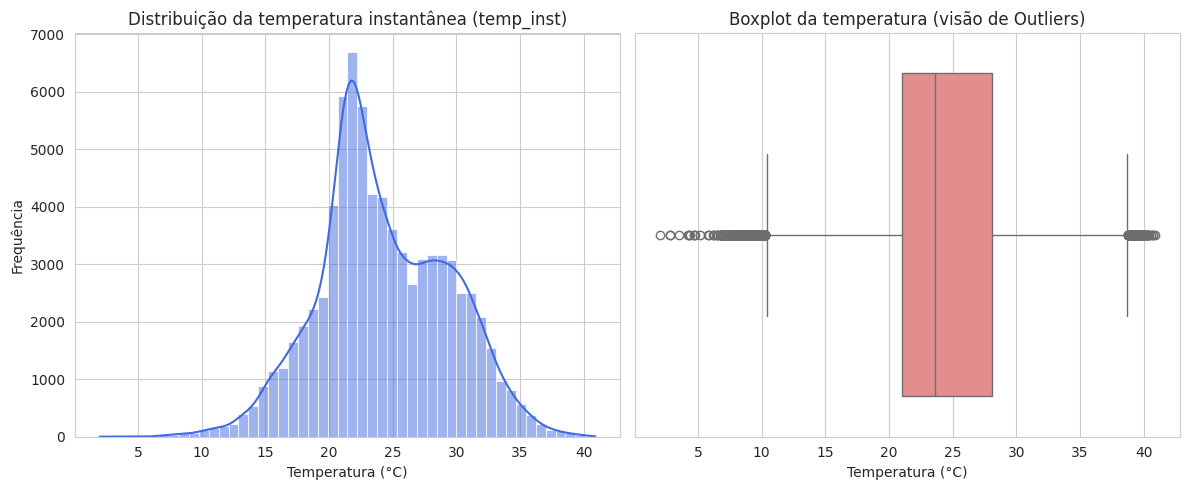

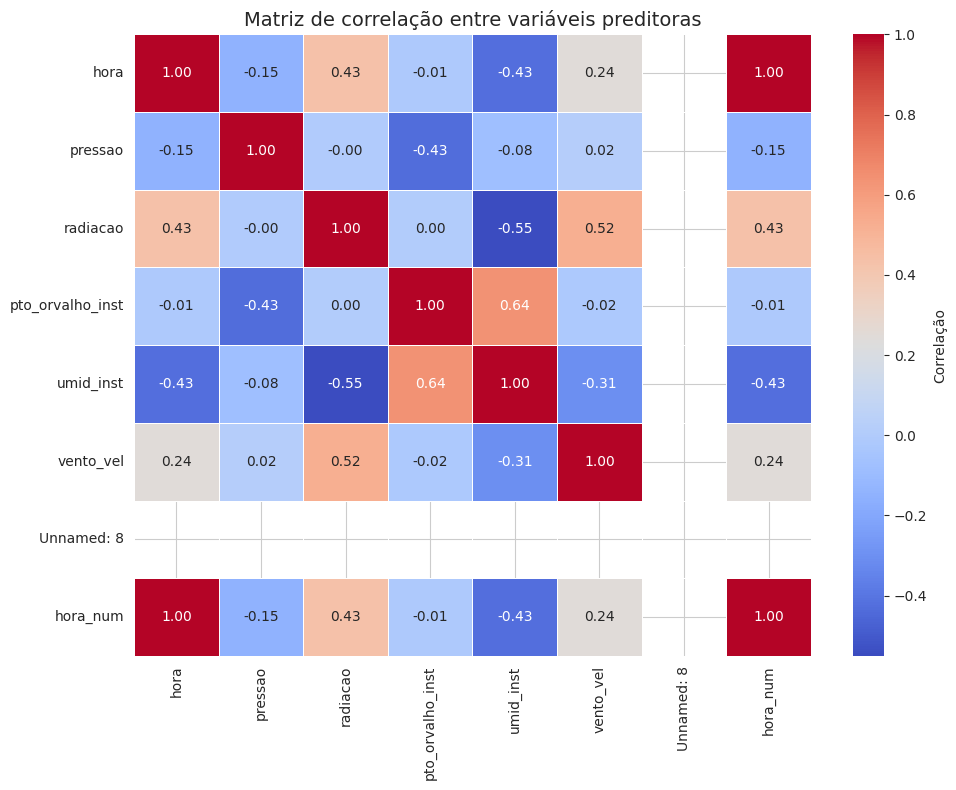

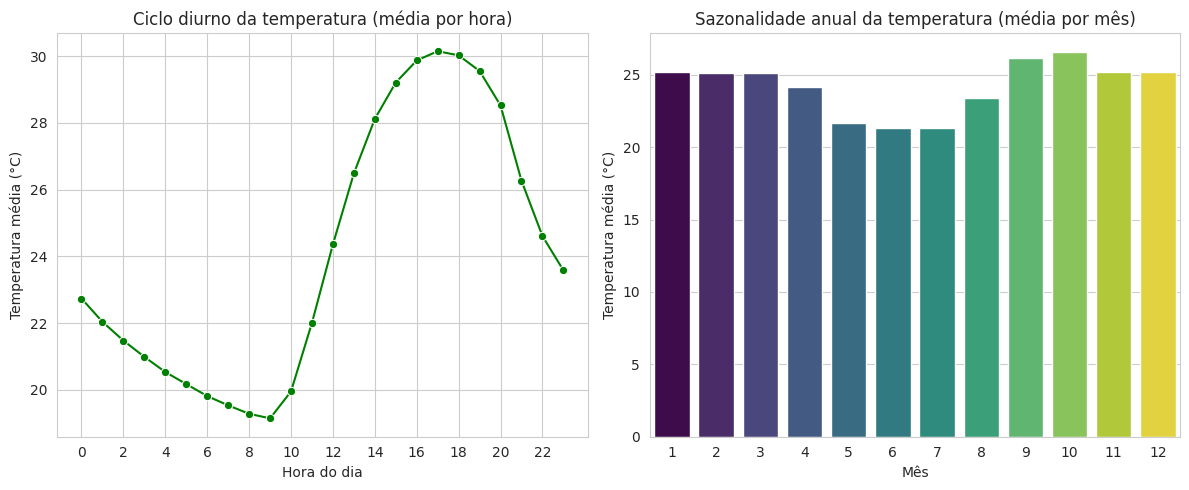

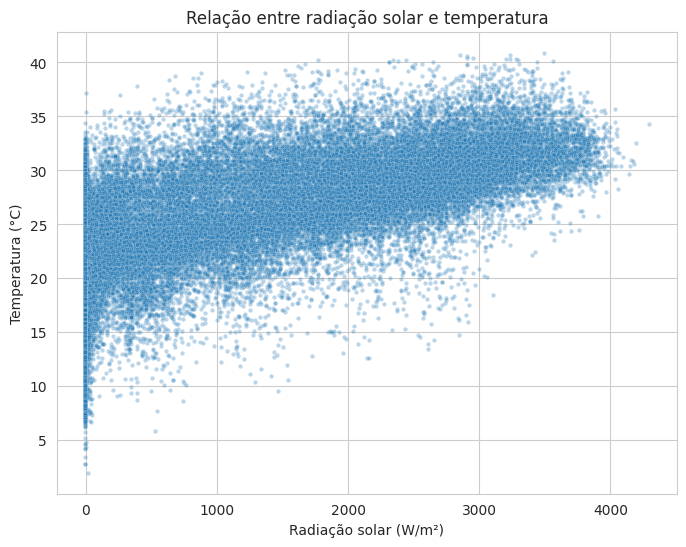

In [21]:
if not pd.api.types.is_datetime64_any_dtype(df_temp_inst['data']):
    df_temp_inst['data'] = pd.to_datetime(df_temp_inst['data'])

if 'ano' not in df_temp_inst.columns:
    df_temp_inst['ano'] = df_temp_inst['data'].dt.year
if 'mes' not in df_temp_inst.columns:
    df_temp_inst['mes'] = df_temp_inst['data'].dt.month
if 'dia' not in df_temp_inst.columns:
    df_temp_inst['dia'] = df_temp_inst['data'].dt.day
if 'dia_semana' not in df_temp_inst.columns:
    df_temp_inst['dia_semana'] = df_temp_inst['data'].dt.dayofweek

if 'hora_num' not in df_temp_inst.columns:
    if df_temp_inst['hora'].dtype == 'object':
        df_temp_inst['hora_num'] = df_temp_inst['hora'].str[:2].astype(int)
    else:
        df_temp_inst['hora_num'] = (df_temp_inst['hora'] // 100).astype(int)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_temp_inst['temp_inst'], bins=50, kde=True, color='royalblue')
plt.title('Distribuição da temperatura instantânea (temp_inst)')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_temp_inst['temp_inst'], color='lightcoral')
plt.title('Boxplot da temperatura (visão de Outliers)')
plt.xlabel('Temperatura (°C)')

plt.tight_layout()
plt.show()

cols_numericas = df_temp_inst.select_dtypes(include=['int64', 'float64']).columns
cols_numericas = [col for col in cols_numericas if col != 'temp_inst']

plt.figure(figsize=(10, 8))
corr = df_temp_inst[cols_numericas].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Correlação'})
plt.title('Matriz de correlação entre variáveis preditoras', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

media_temp_por_hora = df_temp_inst.groupby('hora_num')['temp_inst'].mean().reset_index()
plt.subplot(1, 2, 1)
sns.lineplot(data=media_temp_por_hora, x='hora_num', y='temp_inst', marker='o', color='green')
plt.title('Ciclo diurno da temperatura (média por hora)')
plt.xlabel('Hora do dia')
plt.ylabel('Temperatura média (°C)')
plt.xticks(range(0, 24, 2))

plt.subplot(1, 2, 2)
media_temp_por_mes = df_temp_inst.groupby('mes')['temp_inst'].mean().reset_index()
sns.barplot(data=media_temp_por_mes, x='mes', y='temp_inst', hue='mes', palette='viridis', legend=False)
plt.title('Sazonalidade anual da temperatura (média por mês)')
plt.xlabel('Mês')
plt.ylabel('Temperatura média (°C)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_temp_inst, x='radiacao', y='temp_inst', alpha=0.3, s=10)
plt.title('Relação entre radiação solar e temperatura')
plt.xlabel('Radiação solar (W/m²)')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

# Remoção de colunas inutilizadas

In [22]:
# Coluna "Unnamed: 8" removida do dataset
colunas_para_remover = [col for col in df_temp_inst.columns if 'Unnamed' in col]
df_temp_inst = df_temp_inst.drop(columns=colunas_para_remover, errors='ignore')

print('Colunas restantes:', df_temp_inst.columns.tolist())

Colunas restantes: ['data', 'hora', 'pressao', 'radiacao', 'temp_inst', 'pto_orvalho_inst', 'umid_inst', 'vento_vel', 'ano', 'mes', 'dia', 'dia_semana', 'hora_num']


# Tratamento de valores ausentes

In [23]:
print('Valores nulos antes do tratamento:')
print(df_temp_inst.isnull().sum())

df_temp_inst = df_temp_inst.dropna(subset=['temp_inst', 'pressao', 'radiacao', 'umid_inst', 'pto_orvalho_inst'])

print('\nValores nulos após o tratamento:')
print(df_temp_inst.isnull().sum())

Valores nulos antes do tratamento:
data                   0
hora                   0
pressao             5279
radiacao            5279
temp_inst           5279
pto_orvalho_inst    5284
umid_inst           5285
vento_vel           5279
ano                    0
mes                    0
dia                    0
dia_semana             0
hora_num               0
dtype: int64

Valores nulos após o tratamento:
data                0
hora                0
pressao             0
radiacao            0
temp_inst           0
pto_orvalho_inst    0
umid_inst           0
vento_vel           0
ano                 0
mes                 0
dia                 0
dia_semana          0
hora_num            0
dtype: int64


In [24]:
# Dados faltantes
print(f'As variáveis com mais dados faltantes, em porcentagem(%), são:\n')
((df_temp_inst.isnull().sum() / df_temp_inst.shape[0])*100).sort_values(ascending=False)

As variáveis com mais dados faltantes, em porcentagem(%), são:



,0
data,0.00
hora,0.00
pressao,0.00
radiacao,0.00
temp_inst,0.00
pto_orvalho_inst,0.00
umid_inst,0.00
vento_vel,0.00
ano,0.00
mes,0.00


# Engenharia de Recursos
Modelos de Machine Learning não interpretam o formato de data/texto diretamente. Portanto, convertemos a coluna `data` para o tipo `datetime` e extraímos variáveis numéricas sazonais (ano, mês, dia, dia da semana) que ajudarão os classificadores a entender padrões temporais.

In [25]:
df_temp_inst['data'] = pd.to_datetime(df_temp_inst['data'])

df_temp_inst['ano'] = df_temp_inst['data'].dt.year
df_temp_inst['mes'] = df_temp_inst['data'].dt.month
df_temp_inst['dia'] = df_temp_inst['data'].dt.day
df_temp_inst['dia_semana'] = df_temp_inst['data'].dt.dayofweek

In [26]:
df_temp_inst

,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,ano,mes,dia,dia_semana,hora_num
0,2013-12-03,0,949.30,-3.54,22.30,21.00,92.00,2.30,2013,12,3,1,0
1,2013-12-03,100,949.70,-3.54,22.10,20.60,91.00,2.10,2013,12,3,1,1
2,2013-12-03,200,949.40,-3.54,22.10,20.00,88.00,1.30,2013,12,3,1,2
3,2013-12-03,300,949.10,-3.54,21.90,20.20,90.00,2.30,2013,12,3,1,3
4,2013-12-03,400,948.60,-3.54,21.40,19.80,91.00,1.50,2013,12,3,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83227,2023-06-01,1900,954.20,1195.46,24.90,15.80,57.00,1.60,2023,6,1,3,19
83228,2023-06-01,2000,954.50,462.95,23.10,15.80,64.00,0.80,2023,6,1,3,20
83229,2023-06-01,2100,954.70,8.56,20.00,15.40,75.00,1.20,2023,6,1,3,21
83230,2023-06-01,2200,955.20,-3.54,19.30,15.40,78.00,1.30,2023,6,1,3,22


## Padronização e formatação da coluna de horas
Como a coluna original de horas foi interpretada como numérica, os zeros à esquerda foram omitidos (ex: `0` em vez de `0000`, `100` em vez de `0100`). Para corrigir isto, preenchemos os valores para que tenham sempre 4 dígitos, criamos uma coluna numérica (`hora_num`) para os algoritmos de Machine Learning e formatamos a coluna original no padrão textual legível `HH:MM`.

In [27]:
df_temp_inst['hora'] = df_temp_inst['hora'].astype(str).str.replace(r'\D', '', regex=True)

df_temp_inst['hora'] = df_temp_inst['hora'].str.zfill(4)

df_temp_inst['hora'] = df_temp_inst['hora'].str[:2] + ':' + df_temp_inst['hora'].str[2:]

df_temp_inst.head()

,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,ano,mes,dia,dia_semana,hora_num
0,2013-12-03,00:00,949.30,-3.54,22.30,21.00,92.00,2.30,2013,12,3,1,0
1,2013-12-03,01:00,949.70,-3.54,22.10,20.60,91.00,2.10,2013,12,3,1,1
2,2013-12-03,02:00,949.40,-3.54,22.10,20.00,88.00,1.30,2013,12,3,1,2
3,2013-12-03,03:00,949.10,-3.54,21.90,20.20,90.00,2.30,2013,12,3,1,3
4,2013-12-03,04:00,948.60,-3.54,21.40,19.80,91.00,1.50,2013,12,3,1,4


## Definição da variável alvo (Regressão)

Como o objetivo do trabalho é aplicar **algoritmos de regressão** para prever a temperatura instantânea (`temp_inst`), a variável dependente ($Y$) é contínua (numérica).

Diferente da classificação, não criamos uma categoria binária. O modelo aprenderá diretamente o valor numérico da temperatura com base nas demais variáveis meteorológicas.

Abaixo, separamos as features ($X$) removendo colunas textuais (`data`, `hora`) e a própria temperatura (para não vazar informação). Em seguida, fazemos a divisão em treino (80%) e teste (20%) e aplicamos o `StandardScaler` para padronizar as variáveis numéricas.

In [28]:
df_temp_inst['hora_num'] = df_temp_inst['hora'].str[:2].astype(int)

# X = variáveis preditoras (todas numéricas)
X = df_temp_inst.drop(columns=['temp_inst', 'data', 'hora'], errors='ignore')

# y = variável alvo contínua
y = df_temp_inst['temp_inst']

print("Variáveis preditoras:", X.columns.tolist())
print(f"Total de amostras: {X.shape[0]}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nFormato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")

# escalonamento e normalização dos dados (padronização com média 0 e variância 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nExemplo da primeira linha dos dados de treino escalonados:")
print(X_train_scaled[0].round(4))

Variáveis preditoras: ['pressao', 'radiacao', 'pto_orvalho_inst', 'umid_inst', 'vento_vel', 'ano', 'mes', 'dia', 'dia_semana', 'hora_num']
Total de amostras: 77945

Formato dos dados de treino (X_train): (62356, 10)
Formato dos dados de teste (X_test): (15589, 10)

Exemplo da primeira linha dos dados de treino escalonados:
[-0.14   -0.7588  0.8093  1.5011 -1.2311 -1.506  -0.6749  0.6032 -1.4974
 -0.8289]




---



## Função para avaliação de regressores

Para evitar repetição de código, definimos uma função que treina o modelo, faz previsões no conjunto de teste e retorna as três métricas exigidas: **RMSE** (Raiz do Erro Quadrático Médio), **MAE** (Erro Absoluto Médio) e **R²** (Coeficiente de Determinação).

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def avaliar_regressor(modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return rmse, mae, r2

## Modelo 1: Regressão Linear com Regularização

A Regressão Linear tradicional não possui hiperparâmetros de complexidade. Para evitar overfitting e lidar com multicolinearidade, exploramos três variações com penalização:

1. **Ridge** (regularização L2) – penaliza a soma dos quadrados dos coeficientes.
2. **Lasso** (regularização L1) – penaliza a soma dos valores absolutos, podendo zerar coeficientes (seleção de features).
3. **ElasticNet** – combinação de L1 e L2, controlada pelo parâmetro `l1_ratio`.

Variamos o valor de `alpha` (força da penalização) e `l1_ratio` para encontrar o melhor equilíbrio.

In [30]:
resultados = {}

modelo_ridge = Ridge(alpha=1.0)
rmse_r, mae_r, r2_r = avaliar_regressor(modelo_ridge, X_train_scaled, X_test_scaled, y_train, y_test)
resultados['Ridge (alpha=1)'] = [rmse_r, mae_r, r2_r]

modelo_lasso = Lasso(alpha=0.1, max_iter=10000)
rmse_l, mae_l, r2_l = avaliar_regressor(modelo_lasso, X_train_scaled, X_test_scaled, y_train, y_test)
resultados['Lasso (alpha=0.1)'] = [rmse_l, mae_l, r2_l]

modelo_elastic = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000)
rmse_e, mae_e, r2_e = avaliar_regressor(modelo_elastic, X_train_scaled, X_test_scaled, y_train, y_test)
resultados['ElasticNet (alpha=0.5, l1=0.5)'] = [rmse_e, mae_e, r2_e]

## Modelo 2: Árvore de Decisão para Regressão

A Árvore de Decisão divide o espaço dos dados em regiões com base em regras sequenciais. O principal risco é o overfitting quando a árvore cresce demais. Testamos três profundidades máximas (`max_depth`):

- **30** – árvore muito profunda, propensa a overfitting.
- **10** – profundidade moderada.
- **3** – árvore rasa, possivelmente com underfitting.

In [31]:
from sklearn.tree import DecisionTreeRegressor

dt1 = DecisionTreeRegressor(max_depth=30, random_state=42)
rmse_dt1, mae_dt1, r2_dt1 = avaliar_regressor(dt1, X_train, X_test, y_train, y_test)
resultados['Árvore (max_depth=30)'] = [rmse_dt1, mae_dt1, r2_dt1]

dt2 = DecisionTreeRegressor(max_depth=10, random_state=42)
rmse_dt2, mae_dt2, r2_dt2 = avaliar_regressor(dt2, X_train, X_test, y_train, y_test)
resultados['Árvore (max_depth=10)'] = [rmse_dt2, mae_dt2, r2_dt2]

dt3 = DecisionTreeRegressor(max_depth=3, random_state=42)
rmse_dt3, mae_dt3, r2_dt3 = avaliar_regressor(dt3, X_train, X_test, y_train, y_test)
resultados['Árvore (max_depth=3)'] = [rmse_dt3, mae_dt3, r2_dt3]